In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving student_performance_100_students.csv to student_performance_100_students.csv


In [3]:
df = pd.read_csv("student_performance_100_students.csv")

In [4]:
df.head()

,Course_Name,Course_ID,Attempt_ID,Candidate_Name,Candidate_Email,Mark,Grade
0,Python,C101,1,Arun 1,arun1@gmail.com,53,C
1,Data Analytics,C105,1,Arun 1,arun1@gmail.com,38,F
2,Java,C103,1,Arun 1,arun1@gmail.com,94,A
3,Java,C103,2,Arun 1,arun1@gmail.com,91,A
4,Data Analytics,C105,1,Priya 2,priya2@gmail.com,52,C


In [5]:
df.shape

(488, 7)

In [6]:
df.columns

Index(['Course_Name', 'Course_ID', 'Attempt_ID', 'Candidate_Name',
       'Candidate_Email', 'Mark', 'Grade'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Course_Name      488 non-null    object
 1   Course_ID        488 non-null    object
 2   Attempt_ID       488 non-null    int64 
 3   Candidate_Name   488 non-null    object
 4   Candidate_Email  488 non-null    object
 5   Mark             488 non-null    int64 
 6   Grade            488 non-null    object
dtypes: int64(2), object(5)
memory usage: 26.8+ KB


In [8]:
df.isnull().sum()

,0
Course_Name,0
Course_ID,0
Attempt_ID,0
Candidate_Name,0
Candidate_Email,0
Mark,0
Grade,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
def find_skill_status(mark):
    if mark >= 70:
        return "Strength"
    elif mark >= 50:
        return "Average"
    else:
        return "Weakness"

In [12]:
df["Skill_Status"] = df["Mark"].apply(find_skill_status)

In [13]:
df.head(10)

,Course_Name,Course_ID,Attempt_ID,Candidate_Name,Candidate_Email,Mark,Grade,Skill_Status
0,Python,C101,1,Arun 1,arun1@gmail.com,53,C,Average
1,Data Analytics,C105,1,Arun 1,arun1@gmail.com,38,F,Weakness
2,Java,C103,1,Arun 1,arun1@gmail.com,94,A,Strength
3,Java,C103,2,Arun 1,arun1@gmail.com,91,A,Strength
4,Data Analytics,C105,1,Priya 2,priya2@gmail.com,52,C,Average
5,Aptitude,C104,1,Priya 2,priya2@gmail.com,28,F,Weakness
6,Python,C101,1,Priya 2,priya2@gmail.com,94,A,Strength
7,Python,C101,2,Priya 2,priya2@gmail.com,100,A,Strength
8,SQL,C102,1,Karthik 3,karthik3@gmail.com,25,F,Weakness
9,Aptitude,C104,1,Karthik 3,karthik3@gmail.com,45,D,Weakness


In [14]:
student_summary = df.groupby(
    ["Candidate_Name", "Candidate_Email"]
)["Mark"].mean().reset_index()

In [15]:
student_summary.rename(
    columns={"Mark": "Average_Mark"},
    inplace=True
)

In [16]:
student_summary.head()

,Candidate_Name,Candidate_Email,Average_Mark
0,Aishwarya 18,aishwarya18@gmail.com,32.25
1,Aishwarya 68,aishwarya68@gmail.com,68.75
2,Ajay 11,ajay11@gmail.com,84.80
3,Ajay 61,ajay61@gmail.com,85.20
4,Akash 23,akash23@gmail.com,59.60


In [17]:
def classify_performance(mark):
    if mark >= 80:
        return "High Performer"
    elif mark >= 50:
        return "Medium Performer"
    else:
        return "Poor Performer"

In [18]:
student_summary["Performance"] = student_summary["Average_Mark"].apply(
    classify_performance
)

In [19]:
student_summary.head(10)

,Candidate_Name,Candidate_Email,Average_Mark,Performance
0,Aishwarya 18,aishwarya18@gmail.com,32.25,Poor Performer
1,Aishwarya 68,aishwarya68@gmail.com,68.75,Medium Performer
2,Ajay 11,ajay11@gmail.com,84.80,High Performer
3,Ajay 61,ajay61@gmail.com,85.20,High Performer
4,Akash 23,akash23@gmail.com,59.60,Medium Performer
5,Akash 73,akash73@gmail.com,46.50,Poor Performer
6,Anjali 58,anjali58@gmail.com,59.20,Medium Performer
7,Anjali 8,anjali8@gmail.com,54.00,Medium Performer
8,Arun 1,arun1@gmail.com,69.00,Medium Performer
9,Arun 51,arun51@gmail.com,53.00,Medium Performer


In [20]:
student_summary["Performance"].value_counts()

,count
Performance,
Medium Performer,76
Poor Performer,14
High Performer,10


In [21]:
course_recommendations = {
    "Python": "Python Basics and Problem Solving",
    "SQL": "SQL Fundamentals and Query Practice",
    "Java": "Java Programming Basics",
    "Aptitude": "Quantitative Aptitude Practice",
    "Data Analytics": "Data Analytics Fundamentals"
}

In [22]:
def recommend_course(row):
    if row["Skill_Status"] == "Weakness":
        return course_recommendations.get(
            row["Course_Name"],
            "General Skill Improvement Course"
        )
    else:
        return "No Course Required"

In [23]:
df["Recommended_Course"] = df.apply(
    recommend_course,
    axis=1
)

In [24]:
df[
    [
        "Candidate_Name",
        "Course_Name",
        "Mark",
        "Skill_Status",
        "Recommended_Course"
    ]
].head(20)

,Candidate_Name,Course_Name,Mark,Skill_Status,Recommended_Course
0,Arun 1,Python,53,Average,No Course Required
1,Arun 1,Data Analytics,38,Weakness,Data Analytics Fundamentals
2,Arun 1,Java,94,Strength,No Course Required
3,Arun 1,Java,91,Strength,No Course Required
4,Priya 2,Data Analytics,52,Average,No Course Required
5,Priya 2,Aptitude,28,Weakness,Quantitative Aptitude Practice
6,Priya 2,Python,94,Strength,No Course Required
7,Priya 2,Python,100,Strength,No Course Required
8,Karthik 3,SQL,25,Weakness,SQL Fundamentals and Query Practice
9,Karthik 3,Aptitude,45,Weakness,Quantitative Aptitude Practice


In [25]:
poor_performers = student_summary[
    student_summary["Performance"] == "Poor Performer"
]

In [26]:
poor_performers

,Candidate_Name,Candidate_Email,Average_Mark,Performance
0,Aishwarya 18,aishwarya18@gmail.com,32.250000,Poor Performer
5,Akash 73,akash73@gmail.com,46.500000,Poor Performer
10,Ashwin 33,ashwin33@gmail.com,48.333333,Poor Performer
23,Ganesh 99,ganesh99@gmail.com,46.500000,Poor Performer
27,Gokul 81,gokul81@gmail.com,49.600000,Poor Performer
34,Janani 32,janani32@gmail.com,43.750000,Poor Performer
36,Karthik 3,karthik3@gmail.com,48.000000,Poor Performer
38,Kavya 26,kavya26@gmail.com,49.400000,Poor Performer
46,Lokesh 43,lokesh43@gmail.com,47.333333,Poor Performer
49,Madhan 89,madhan89@gmail.com,49.166667,Poor Performer


In [27]:
good_performers = student_summary[
    student_summary["Performance"] == "High Performer"
]

In [28]:
good_performers

,Candidate_Name,Candidate_Email,Average_Mark,Performance
2,Ajay 11,ajay11@gmail.com,84.800000,High Performer
3,Ajay 61,ajay61@gmail.com,85.200000,High Performer
14,Bhavya 48,bhavya48@gmail.com,81.800000,High Performer
17,Deepika 70,deepika70@gmail.com,90.375000,High Performer
21,Divya 54,divya54@gmail.com,87.333333,High Performer
43,Kishore 91,kishore91@gmail.com,91.000000,High Performer
57,Nandhini 86,nandhini86@gmail.com,81.777778,High Performer
64,Pooja 16,pooja16@gmail.com,93.833333,High Performer
67,Praveen 79,praveen79@gmail.com,83.875000,High Performer
89,Suresh 87,suresh87@gmail.com,88.500000,High Performer


In [29]:
pairs = []

good_list = good_performers["Candidate_Name"].tolist()

for i, poor_student in enumerate(poor_performers["Candidate_Name"]):
    mentor = good_list[i % len(good_list)]

    pairs.append({
        "Poor_Performer": poor_student,
        "Assigned_Mentor": mentor
    })

In [30]:
mentor_pairs = pd.DataFrame(pairs)

In [31]:
mentor_pairs

,Poor_Performer,Assigned_Mentor
0,Aishwarya 18,Ajay 11
1,Akash 73,Ajay 61
2,Ashwin 33,Bhavya 48
3,Ganesh 99,Deepika 70
4,Gokul 81,Divya 54
5,Janani 32,Kishore 91
6,Karthik 3,Nandhini 86
7,Kavya 26,Pooja 16
8,Lokesh 43,Praveen 79
9,Madhan 89,Suresh 87


In [32]:
df = df.sort_values(
    ["Candidate_Email", "Course_ID", "Attempt_ID"]
)

In [33]:
df["Previous_Mark"] = df.groupby(
    ["Candidate_Email", "Course_ID"]
)["Mark"].shift(1)

In [34]:
df["Mark_Change"] = df["Mark"] - df["Previous_Mark"]

In [35]:
def improvement_status(change):
    if pd.isna(change):
        return "First Attempt"
    elif change > 0:
        return "Improving"
    elif change < 0:
        return "Declining"
    else:
        return "No Change"

In [36]:
df["Improvement_Status"] = df["Mark_Change"].apply(
    improvement_status
)

In [37]:
df[
    [
        "Candidate_Name",
        "Course_Name",
        "Attempt_ID",
        "Previous_Mark",
        "Mark",
        "Mark_Change",
        "Improvement_Status"
    ]
].head(20)

,Candidate_Name,Course_Name,Attempt_ID,Previous_Mark,Mark,Mark_Change,Improvement_Status
81,Aishwarya 18,Python,1,NaN,34,NaN,First Attempt
82,Aishwarya 18,SQL,1,NaN,32,NaN,First Attempt
83,Aishwarya 18,SQL,2,32.0,34,2.0,Improving
84,Aishwarya 18,Java,1,NaN,29,NaN,First Attempt
324,Aishwarya 68,Python,1,NaN,92,NaN,First Attempt
321,Aishwarya 68,SQL,1,NaN,48,NaN,First Attempt
322,Aishwarya 68,SQL,2,48.0,49,1.0,Improving
323,Aishwarya 68,Java,1,NaN,86,NaN,First Attempt
43,Ajay 11,Python,1,NaN,79,NaN,First Attempt
44,Ajay 11,Python,2,79.0,93,14.0,Improving


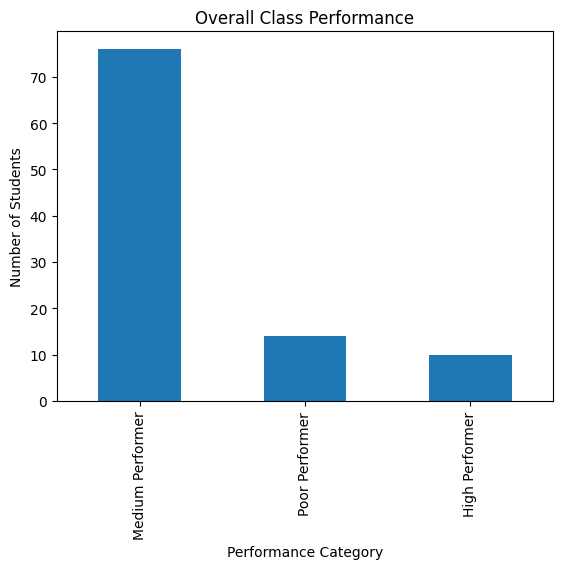

In [38]:
student_summary["Performance"].value_counts().plot(
    kind="bar"
)

plt.title("Overall Class Performance")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

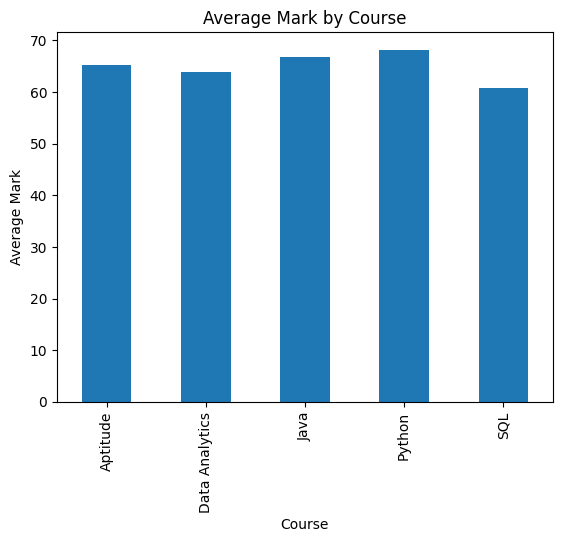

In [39]:
df.groupby("Course_Name")["Mark"].mean().plot(
    kind="bar"
)

plt.title("Average Mark by Course")
plt.xlabel("Course")
plt.ylabel("Average Mark")
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [41]:
def record_performance(mark):
    if mark >= 80:
        return "High Performer"
    elif mark >= 50:
        return "Medium Performer"
    else:
        return "Poor Performer"

df["Performance_Category"] = df["Mark"].apply(record_performance)

In [42]:
df[
    [
        "Candidate_Name",
        "Course_Name",
        "Attempt_ID",
        "Mark",
        "Performance_Category"
    ]
].head(10)

,Candidate_Name,Course_Name,Attempt_ID,Mark,Performance_Category
81,Aishwarya 18,Python,1,34,Poor Performer
82,Aishwarya 18,SQL,1,32,Poor Performer
83,Aishwarya 18,SQL,2,34,Poor Performer
84,Aishwarya 18,Java,1,29,Poor Performer
324,Aishwarya 68,Python,1,92,High Performer
321,Aishwarya 68,SQL,1,48,Poor Performer
322,Aishwarya 68,SQL,2,49,Poor Performer
323,Aishwarya 68,Java,1,86,High Performer
43,Ajay 11,Python,1,79,Medium Performer
44,Ajay 11,Python,2,93,High Performer


In [43]:
X = df[["Mark", "Attempt_ID"]]

y = df["Performance_Category"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [46]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [47]:
predictions = model.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 100.0 %


In [49]:
print(classification_report(y_test, predictions))

                  precision    recall  f1-score   support

  High Performer       1.00      1.00      1.00        29
Medium Performer       1.00      1.00      1.00        44
  Poor Performer       1.00      1.00      1.00        25

        accuracy                           1.00        98
       macro avg       1.00      1.00      1.00        98
    weighted avg       1.00      1.00      1.00        98



In [ ]:
#Test the ML Model Manually

In [50]:
mark = 45
attempt_id = 2

new_student = pd.DataFrame(
    [[mark, attempt_id]],
    columns=["Mark", "Attempt_ID"]
)

prediction = model.predict(new_student)

print("Predicted Performance:", prediction[0])

Predicted Performance: Poor Performer


In [52]:
mark = 85
attempt_id = 1
new_student = pd.DataFrame(
    [[mark, attempt_id]],
    columns=["Mark", "Attempt_ID"]
)

prediction = model.predict(new_student)

print("Predicted Performance:", prediction[0])

Predicted Performance: High Performer


In [ ]:
#Complete Analysis Report

In [53]:
df.to_csv(
    "complete_performance_analysis.csv",
    index=False
)

In [54]:
student_summary.to_csv(
    "student_summary_report.csv",
    index=False
)

In [55]:
weakness_report = df[
    df["Skill_Status"] == "Weakness"
][
    [
        "Candidate_Name",
        "Candidate_Email",
        "Course_Name",
        "Mark",
        "Recommended_Course"
    ]
]

In [56]:
weakness_report.to_csv(
    "weakness_and_recommendation_report.csv",
    index=False
)

In [57]:
mentor_pairs.to_csv(
    "mentor_pairing_report.csv",
    index=False
)

In [58]:
print("Reports created successfully!")

print("1. complete_performance_analysis.csv")
print("2. student_summary_report.csv")
print("3. weakness_and_recommendation_report.csv")
print("4. mentor_pairing_report.csv")

Reports created successfully!
1. complete_performance_analysis.csv
2. student_summary_report.csv
3. weakness_and_recommendation_report.csv
4. mentor_pairing_report.csv


In [59]:
from google.colab import files

In [60]:
files.download("student_summary_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
files.download("weakness_and_recommendation_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
files.download("mentor_pairing_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
files.download("complete_performance_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
total_students = student_summary["Candidate_Email"].nunique()

print("Total Students:", total_students)

Total Students: 100


In [65]:
class_average = student_summary["Average_Mark"].mean()

print("Class Average:", round(class_average, 2))

Class Average: 64.18


In [66]:
poor_count = len(
    student_summary[
        student_summary["Performance"] == "Poor Performer"
    ]
)

print("Poor Performers:", poor_count)

Poor Performers: 14


In [67]:
high_count = len(
    student_summary[
        student_summary["Performance"] == "High Performer"
    ]
)

print("High Performers:", high_count)

High Performers: 10


In [68]:
print("========== CLASS PERFORMANCE DASHBOARD ==========")

print("Total Students:", total_students)
print("Class Average:", round(class_average, 2))
print("High Performers:", high_count)
print("Poor Performers:", poor_count)

print("=================================================")

========== CLASS PERFORMANCE DASHBOARD ==========
Total Students: 100
Class Average: 64.18
High Performers: 10
Poor Performers: 14


In [69]:
improving_students = df[
    df["Improvement_Status"] == "Improving"
]

In [70]:
improving_students[
    [
        "Candidate_Name",
        "Course_Name",
        "Attempt_ID",
        "Previous_Mark",
        "Mark",
        "Mark_Change"
    ]
]

,Candidate_Name,Course_Name,Attempt_ID,Previous_Mark,Mark,Mark_Change
83,Aishwarya 18,SQL,2,32.0,34,2.0
322,Aishwarya 68,SQL,2,48.0,49,1.0
44,Ajay 11,Python,2,79.0,93,14.0
47,Ajay 11,Aptitude,2,84.0,95,11.0
295,Ajay 61,Data Analytics,2,83.0,100,17.0
...,...,...,...,...,...,...
470,Varun 97,Aptitude,2,62.0,79,17.0
88,Vignesh 19,Data Analytics,2,85.0,87,2.0
326,Vignesh 69,Data Analytics,2,62.0,64,2.0
259,Vijay 55,Data Analytics,2,42.0,51,9.0


In [71]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 60.6 MB/s eta 0:00:00


In [73]:
%%writefile app.py

import streamlit as st

st.set_page_config(
    page_title="Candidate Performance Analysis",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Candidate Performance Analysis & Recommendation Tool")

st.write(
    "Upload student performance data to analyze strengths, "
    "weaknesses, recommendations and improvement."
)

Overwriting app.py


In [74]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# PAGE SETTINGS
# -------------------------------------------------

st.set_page_config(
    page_title="Candidate Performance Analysis",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Candidate Performance Analysis & Recommendation Tool")

st.write(
    "Upload a CSV or Excel file to analyze student performance."
)

# -------------------------------------------------
# FILE UPLOAD
# -------------------------------------------------

uploaded_file = st.file_uploader(
    "Upload Student Performance Dataset",
    type=["csv", "xlsx"]
)

if uploaded_file is not None:

    # Read CSV or Excel
    if uploaded_file.name.endswith(".csv"):
        df = pd.read_csv(uploaded_file)

    else:
        df = pd.read_excel(uploaded_file)

    st.success("Dataset uploaded successfully!")

    # -------------------------------------------------
    # DATA PREPROCESSING
    # -------------------------------------------------

    df = df.drop_duplicates()

    df["Mark"] = pd.to_numeric(
        df["Mark"],
        errors="coerce"
    )

    df = df.dropna(
        subset=[
            "Candidate_Email",
            "Course_Name",
            "Mark"
        ]
    )

    # -------------------------------------------------
    # STRENGTH AND WEAKNESS
    # -------------------------------------------------

    def find_skill_status(mark):

        if mark >= 70:
            return "Strength"

        elif mark >= 50:
            return "Average"

        else:
            return "Weakness"

    df["Skill_Status"] = df["Mark"].apply(
        find_skill_status
    )

    # -------------------------------------------------
    # COURSE RECOMMENDATIONS
    # -------------------------------------------------

    course_recommendations = {

        "Python":
        "Python Basics and Problem Solving",

        "SQL":
        "SQL Fundamentals and Query Practice",

        "Java":
        "Java Programming Basics",

        "Aptitude":
        "Quantitative Aptitude Practice",

        "Data Analytics":
        "Data Analytics Fundamentals"
    }

    def recommend_course(row):

        if row["Skill_Status"] == "Weakness":

            return course_recommendations.get(
                row["Course_Name"],
                "General Skill Improvement Course"
            )

        return "No Course Required"

    df["Recommended_Course"] = df.apply(
        recommend_course,
        axis=1
    )

    # -------------------------------------------------
    # STUDENT SUMMARY
    # -------------------------------------------------

    student_summary = (

        df.groupby(
            [
                "Candidate_Name",
                "Candidate_Email"
            ]
        )["Mark"]

        .mean()

        .reset_index()

    )

    student_summary.rename(

        columns={
            "Mark": "Average_Mark"
        },

        inplace=True

    )

    # -------------------------------------------------
    # PERFORMANCE CLASSIFICATION
    # -------------------------------------------------

    def classify_performance(mark):

        if mark >= 80:
            return "High Performer"

        elif mark >= 50:
            return "Medium Performer"

        else:
            return "Poor Performer"

    student_summary["Performance"] = (

        student_summary["Average_Mark"]

        .apply(classify_performance)

    )

    # -------------------------------------------------
    # IMPROVEMENT TRACKING
    # -------------------------------------------------

    df = df.sort_values(

        [
            "Candidate_Email",
            "Course_ID",
            "Attempt_ID"
        ]

    )

    df["Previous_Mark"] = (

        df.groupby(
            [
                "Candidate_Email",
                "Course_ID"
            ]
        )["Mark"]

        .shift(1)

    )

    df["Mark_Change"] = (

        df["Mark"]
        -
        df["Previous_Mark"]

    )

    def improvement_status(change):

        if pd.isna(change):
            return "First Attempt"

        elif change > 0:
            return "Improving"

        elif change < 0:
            return "Declining"

        else:
            return "No Change"

    df["Improvement_Status"] = (

        df["Mark_Change"]

        .apply(improvement_status)

    )

    # -------------------------------------------------
    # DASHBOARD
    # -------------------------------------------------

    st.header("📊 Class Performance Dashboard")

    total_students = (

        student_summary[
            "Candidate_Email"
        ].nunique()

    )

    class_average = (

        student_summary[
            "Average_Mark"
        ].mean()

    )

    high_count = len(

        student_summary[

            student_summary[
                "Performance"
            ]
            ==
            "High Performer"

        ]

    )

    poor_count = len(

        student_summary[

            student_summary[
                "Performance"
            ]
            ==
            "Poor Performer"

        ]

    )

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Students",
        total_students
    )

    col2.metric(
        "Class Average",
        round(class_average, 2)
    )

    col3.metric(
        "High Performers",
        high_count
    )

    col4.metric(
        "Poor Performers",
        poor_count
    )

    # -------------------------------------------------
    # PERFORMANCE GRAPH
    # -------------------------------------------------

    st.subheader(
        "Overall Performance Distribution"
    )

    performance_counts = (

        student_summary[
            "Performance"
        ].value_counts()

    )

    st.bar_chart(
        performance_counts
    )

    # -------------------------------------------------
    # COURSE PERFORMANCE
    # -------------------------------------------------

    st.subheader(
        "Average Mark by Course"
    )

    course_average = (

        df.groupby(
            "Course_Name"
        )["Mark"]

        .mean()

    )

    st.bar_chart(
        course_average
    )

    # -------------------------------------------------
    # STUDENT SEARCH
    # -------------------------------------------------

    st.header(
        "👤 Student Performance Analysis"
    )

    student_names = sorted(

        df[
            "Candidate_Name"
        ].unique()

    )

    selected_student = st.selectbox(

        "Select a Student",

        student_names

    )

    student_data = df[

        df[
            "Candidate_Name"
        ]
        ==
        selected_student

    ]

    student_info = student_summary[

        student_summary[
            "Candidate_Name"
        ]
        ==
        selected_student

    ]

    # -------------------------------------------------
    # OVERALL PERFORMANCE
    # -------------------------------------------------

    if not student_info.empty:

        average_mark = (

            student_info[
                "Average_Mark"
            ].iloc[0]

        )

        performance = (

            student_info[
                "Performance"
            ].iloc[0]

        )

        st.subheader(
            "Overall Performance"
        )

        st.write(
            "Average Mark:",
            round(average_mark, 2)
        )

        st.write(
            "Performance Category:",
            performance
        )

    # -------------------------------------------------
    # STRENGTHS
    # -------------------------------------------------

    st.subheader("💪 Strengths")

    strengths = student_data[

        student_data[
            "Skill_Status"
        ]
        ==
        "Strength"

    ]

    if not strengths.empty:

        st.dataframe(

            strengths[
                [
                    "Course_Name",
                    "Mark",
                    "Grade"
                ]
            ]

        )

    else:

        st.info(
            "No strengths identified."
        )

    # -------------------------------------------------
    # WEAKNESSES
    # -------------------------------------------------

    st.subheader("⚠️ Weaknesses")

    weaknesses = student_data[

        student_data[
            "Skill_Status"
        ]
        ==
        "Weakness"

    ]

    if not weaknesses.empty:

        st.dataframe(

            weaknesses[
                [
                    "Course_Name",
                    "Mark",
                    "Grade"
                ]
            ]

        )

    else:

        st.success(
            "No weaknesses identified."
        )

    # -------------------------------------------------
    # COURSE RECOMMENDATIONS
    # -------------------------------------------------

    st.subheader(
        "📚 Recommended To-Do Courses"
    )

    recommendations = (

        weaknesses[

            [
                "Course_Name",
                "Recommended_Course"
            ]

        ]

        .drop_duplicates()

    )

    if not recommendations.empty:

        st.dataframe(
            recommendations
        )

    else:

        st.success(
            "No additional course required."
        )

    # -------------------------------------------------
    # IMPROVEMENT
    # -------------------------------------------------

    st.subheader(
        "📈 Performance Improvement"
    )

    st.dataframe(

        student_data[

            [
                "Course_Name",
                "Attempt_ID",
                "Previous_Mark",
                "Mark",
                "Mark_Change",
                "Improvement_Status"
            ]

        ]

    )

    # -------------------------------------------------
    # MENTOR PAIRING
    # -------------------------------------------------

    st.header(
        "🤝 Mentor Pairing"
    )

    poor_students = student_summary[

        student_summary[
            "Performance"
        ]
        ==
        "Poor Performer"

    ]

    good_students = student_summary[

        student_summary[
            "Performance"
        ]
        ==
        "High Performer"

    ]

    pairs = []

    good_list = (

        good_students[
            "Candidate_Name"
        ].tolist()

    )

    if len(good_list) > 0:

        for i, poor_student in enumerate(

            poor_students[
                "Candidate_Name"
            ]

        ):

            mentor = (

                good_list[
                    i % len(good_list)
                ]

            )

            pairs.append(

                {
                    "Poor_Performer":
                    poor_student,

                    "Assigned_Mentor":
                    mentor
                }

            )

    mentor_pairs = pd.DataFrame(pairs)

    if not mentor_pairs.empty:

        st.dataframe(
            mentor_pairs
        )

    else:

        st.info(
            "No mentor pairing available."
        )

    # -------------------------------------------------
    # DOWNLOAD REPORTS
    # -------------------------------------------------

    st.header(
        "📥 Download Reports"
    )

    complete_report = (

        df.to_csv(
            index=False
        )

        .encode("utf-8")

    )

    st.download_button(

        label=
        "Download Complete Analysis Report",

        data=
        complete_report,

        file_name=
        "complete_performance_analysis.csv",

        mime=
        "text/csv"

    )

    summary_report = (

        student_summary.to_csv(
            index=False
        )

        .encode("utf-8")

    )

    st.download_button(

        label=
        "Download Student Summary Report",

        data=
        summary_report,

        file_name=
        "student_summary_report.csv",

        mime=
        "text/csv"

    )

else:

    st.info(
        "Please upload a CSV or Excel dataset to begin."
    )

Overwriting app.py


In [75]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [76]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠹

In [77]:
!curl ipv4.icanhazip.com

104.199.208.173


In [80]:
!lt --port 8501

your url is: https://short-lands-spend.loca.lt
^C


In [81]:
!pkill -f streamlit

In [82]:
!streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &

In [83]:
!curl http://localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig

In [85]:
!lt --port 8501

your url is: https://eighty-dodos-sin.loca.lt
^C


In [86]:
!curl -I http://localhost:8501

curl: (7) Failed to connect to localhost port 8501 after 0 ms: Connection refused


In [87]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > streamlit.log 2>&1 &

In [88]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Mon, 13 Jul 2026 04:47:34 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 6602
last-modified: Mon, 13 Jul 2026 04:26:52 GMT
etag: "7059c81e919cc6140c9193c95139400f"
cache-control: no-cache



In [89]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared

In [90]:
!chmod +x cloudflared

In [91]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-13T04:49:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-13T04:49:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-13T04:49:32Z INF +--------------------------------------------------------------------------------------------+
2026-07-13T04:49:32Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-13T04:49:32Z INF |  https://wellness-shelf-compiled-widespread.trycloudfl

In [93]:
student_summary["Performance"].value_counts()

,count
Performance,
Medium Performer,76
Poor Performer,14
High Performer,10


In [94]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-13T05:01:14Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-13T05:01:14Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-13T05:01:18Z INF +--------------------------------------------------------------------------------------------+
2026-07-13T05:01:18Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-13T05:01:18Z INF |  https://choice-seo-detail-particle.trycloudflare.com 

In [95]:
!curl -I http://localhost:8501

curl: (7) Failed to connect to localhost port 8501 after 0 ms: Connection refused


In [96]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > streamlit.log 2>&1 &

In [97]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Mon, 13 Jul 2026 05:03:38 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 6602
last-modified: Mon, 13 Jul 2026 04:26:52 GMT
etag: "7059c81e919cc6140c9193c95139400f"
cache-control: no-cache



In [98]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-13T05:03:57Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-13T05:03:57Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-13T05:04:04Z INF +--------------------------------------------------------------------------------------------+
2026-07-13T05:04:04Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-13T05:04:04Z INF |  https://speech-best-contracts-conflict.trycloudflare.

In [99]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
files.download("student_performance_100_students.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>